# Imports

In [ ]:
import shutil
import re
import os
import sys
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
from scipy import stats
import pickle

# import fastai.tabular.all as fasttab
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestClassifier,  GradientBoostingRegressor
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.utils import resample
import sklearn.metrics as skm


sys.path.append('/mnt/scripts/biliseq_he_class2')
from helpers import anno as annoHelper
%load_ext autoreload
%autoreload 2

results = Path('/mnt/results/v8/')
models = results.joinpath('models')
use_model = 'densenet169_10fold_1rep_1000bal_224px'
method = 'fold'
# use_model = 'densenet169_1fold_1rep_10933bal_224px'
# method = 'slide'
csv_path = models.joinpath(use_model).joinpath('csv')
logs = Path('/mnt/logs/v8/training').joinpath('%s_v1' % use_model)
sampleinfo = Path('/mnt/sampleinfo')
feat_path = results.joinpath('features').joinpath(use_model)
feat_path.mkdir(parents=True,exist_ok=True)
slide_df = pd.read_csv(sampleinfo.joinpath('slide_df_v8.0_44.tsv'),sep='\t').drop(columns=['Unnamed: 0'])
infer_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('infer_csv')
tab_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('tab_models')
tab_path.mkdir(parents=True,exist_ok=True)

In [ ]:
def calc_feats(slide_df,
               tile_df,
               put_pos_thresh=0.16,
               norm=True):
    more_feat = pd.DataFrame([])
    slides = slide_df.slide_num.values
    best_t = put_pos_thresh
    for slide in slides:
        use = tile_df.slide == slide
        tsub=tile_df.loc[use,:].reset_index(drop=True)
        dat = tsub.p_pos.values
        more_feat.loc[slide,'mean_ppos'] = np.mean(dat)
        more_feat.loc[slide,'std_ppos'] = np.std(dat)
        more_feat.loc[slide,'median_ppos'] = np.median(dat)
        more_feat.loc[slide,'var_ppos'] = np.var(dat)        
        more_feat.loc[slide,'mean_ppos_over_bestt'] = int(np.mean(dat) > best_t)
        
        put_pos = dat>best_t
        if any(put_pos):
            more_feat.loc[slide,'prop_ppos'] = np.sum(put_pos)/len(dat)
            more_feat.loc[slide,'put_pos_mean'] = np.mean(dat[put_pos])
            more_feat.loc[slide,'put_pos_psum'] = np.sum(dat[put_pos])
            more_feat.loc[slide,'put_pos_std'] = np.std(dat[put_pos])
            more_feat.loc[slide,'put_pos_max'] = np.max(dat[put_pos])
            more_feat.loc[slide,'put_pos_min'] = np.min(dat[put_pos])
            more_feat.loc[slide,'put_pos_var'] = np.var(dat[put_pos])
        else:
            more_feat.loc[slide,'prop_ppos'] = 0
            more_feat.loc[slide,'put_pos_mean'] = 0
            more_feat.loc[slide,'put_pos_psum'] = 0
            more_feat.loc[slide,'put_pos_std'] = 0
            more_feat.loc[slide,'put_pos_max'] = 0
            more_feat.loc[slide,'put_pos_min'] = 0
            more_feat.loc[slide,'put_pos_var'] = 0
        # mode = stats.mode(dat[put_pos])
        # more_feat.loc[slide,'put_pos_mode'] = mode[0][0]
        # more_feat.loc[slide,'put_pos_modebins'] = mode[1][0]
        
        more_feat.loc[slide,'put_neg_max'] = np.max(dat[~put_pos])
        more_feat.loc[slide,'put_neg_psum'] = np.sum(dat[~put_pos])
        more_feat.loc[slide,'put_neg_mean'] = np.mean(dat[~put_pos])
        more_feat.loc[slide,'put_neg_min'] = np.min(dat[~put_pos])
        more_feat.loc[slide,'put_neg_std'] = np.std(dat[~put_pos])
        more_feat.loc[slide,'put_neg_var'] = np.var(dat[~put_pos])
        # mode = stats.mode(dat[~put_pos])
        # more_feat.loc[slide,'put_neg_mode'] = mode[0][0]
        # more_feat.loc[slide,'put_neg_modebins'] = mode[1][0]
        
    stat_feat = more_feat.values
    if norm:            
        stat_feat = (stat_feat - np.min(stat_feat,axis=0))
        stat_feat = (stat_feat / np.max(stat_feat,axis=0))

    return stat_feat

# Load training dataset (overfit (spatial) predictions for tile-> WSI model training --> oK)

In [5]:
results

PosixPath('/mnt/results/v8')

In [ ]:
overfit = False
if overfit:
    use_model = 'densenet169_1fold_1rep_10933bal_224px'
    feat_path = results.joinpath('features').joinpath(use_model)
    tt = pd.read_csv(feat_path.joinpath('20quantiles_12dim_44slides_neighborhood_normed_density_v2.csv'),
                    index_col=0)
    tile_df = pd.read_csv(feat_path.joinpath('tile_df_574187.csv'))
else:
    use_model = 'densenet169_10fold_1rep_1000bal_224px'
    feat_path = results.joinpath('features').joinpath(use_model)
    tt = pd.read_csv(feat_path.joinpath('20quantiles_12dim_44slides_neighborhood_normed_density_v2.csv'),
                      index_col=0)
    tile_df = pd.read_csv(feat_path.joinpath('tile_df_574187.csv'))   
npcs = 44
seed = 35
whiten = False
all_space = tt.copy()
all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T
pca = PCA(n_components = npcs, 
          whiten=whiten,
          random_state=seed) # whiten=True)
X_r0 = pca.fit(all_space).transform(all_space)
use_norm = True
use_thresh = 0.25
stat_feat =calc_feats(slide_df,
                      tile_df,
                      put_pos_thresh=use_thresh,
                      norm= use_norm) 
all_feat = np.concatenate((stat_feat,
                           X_r0),
                           axis=1) 
# all_feat = stat_feat #Note: This performs worse, maybe around 85% accuracy
print(all_feat.shape)
print('Finished')

(44, 62)
Finished


# Fit gradient boost & rand forest

In [17]:
kfold = 10
nrep = 10
seed = 35
bal_slides = True
use_rf = True
splitter = RepeatedKFold(n_splits=kfold,
                         n_repeats=nrep,
                         random_state=seed)
fold_rep = 0
preds = pd.DataFrame(np.zeros((slide_df.shape[0],nrep))+np.nan)
preds.index = slide_df.index

preds_rf = pd.DataFrame(np.zeros((slide_df.shape[0],nrep))+np.nan)
preds_rf.index = slide_df.index
keep_ests = []
keep_rf_ests = []
rep=-1
for slide_train_idx, slide_test_idx in splitter.split(slide_df.loc[:, 'slide'],
                                                  slide_df.loc[:, 'group'],
                                                  groups=slide_df.loc[:, 'slide']):
    
    if (fold_rep % kfold) == 0:
        rep = rep+1
        print('\n Rep %d, Fold: ' % rep , end='')
    else:
        print('%d,' % (fold_rep % kfold), end='')
    
    sets = [slide_train_idx, slide_test_idx]
    set_lab = ['train', 'valid']
    df_list = []
    pos_idx = slide_df.loc[slide_train_idx, 'class'] == True
    neg_idx = slide_df.loc[slide_train_idx, 'class'] == False
    npos = np.sum(pos_idx)  # n pos
    nneg = np.sum(neg_idx)  # n neg
    if bal_slides:
        if npos > nneg:
            use = nneg
        elif nneg > npos:
            use = npos
        else:
            use= npos
        t_pos = resample(slide_train_idx[pos_idx],
                                   replace = False,
                                   n_samples = use,
                                   random_state = seed)
        t_neg = resample(slide_train_idx[neg_idx],
                           replace = False,
                           n_samples = use,
                           random_state = seed)
        slide_train_idx = np.concatenate((t_pos,t_neg))
   
    X = all_feat[slide_train_idx,:]
    X_val = all_feat[slide_test_idx,:]
    y = slide_df.loc[slide_train_idx,'class'].values.astype(float)
    y_val = slide_df.loc[slide_test_idx,'class'].values.astype(float)
    
    est = GradientBoostingRegressor(random_state=seed).fit(X, y)
    pred =   est.predict(X_val)
    preds.iloc[slide_test_idx,rep]=pred
    keep_ests.append(est)
    
    if use_rf:
        est2 = RandomForestClassifier(random_state=seed).fit(X,y)
        pred2 =  est2.predict_proba(X_val)[:,1]  
        preds_rf.iloc[slide_test_idx,rep]=pred2
        keep_rf_ests.append(est2)
    fold_rep = fold_rep + 1


 Rep 0, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 1, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 2, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 3, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 4, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 5, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 6, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 7, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 8, Fold: 1,2,3,4,5,6,7,8,9,
 Rep 9, Fold: 1,2,3,4,5,6,7,8,9,

# Save fitted models

In [13]:
use_model = 'densenet169_10fold_1rep_1000bal_224px'
tab_path = Path('/mnt/results/v8/models/').joinpath(use_model).joinpath('tab_models')
rep = -1
gb_path = tab_path.joinpath('gb')
gb_path.mkdir(parents=True,exist_ok=True)
rf_path = tab_path.joinpath('rf')
rf_path.mkdir(parents=True,exist_ok=True)
print(gb_path,rf_path)
for fold_rep in range(0,len(keep_ests)):
    fold = (fold_rep % kfold)
    if fold == 0:
        rep = rep+1
        
    fn='%02.0f_%02.0frep_%02.0ffold.pkl' % (fold_rep,rep,fold)
    # print(rf_path.joinpath(fn))
   
    pickle.dump(keep_ests[fold_rep],
                open(gb_path.joinpath(fn), 'wb'))
    pickle.dump(keep_rf_ests[fold_rep],
                open(rf_path.joinpath(fn), 'wb'))
print('Finished')

/mnt/results/v8/models/densenet169_10fold_1rep_1000bal_224px/tab_models/gb /mnt/results/v8/models/densenet169_10fold_1rep_1000bal_224px/tab_models/rf
Finished



Accuracy 0.9090909090909091 
Specificity 0.9230769230769231 
Sensitivity 0.8888888888888888

Accuracy 0.8863636363636364 
Specificity 0.8846153846153846 
Sensitivity 0.8888888888888888


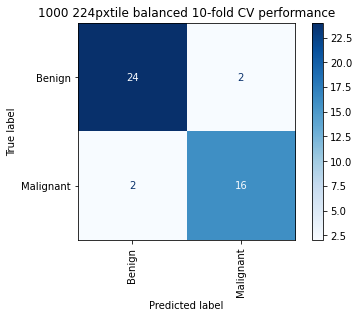

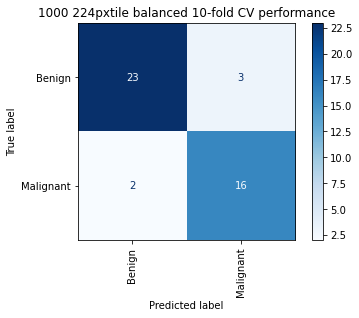

In [20]:
table_norm = False
y_pred = np.nanmean(preds.values,axis=1) > 0.5
y_true = slide_df.loc[:,'class'].values
cm = skm.confusion_matrix(y_true.astype(int), 
                          y_pred.astype(int))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('1000 224pxtile balanced 10-fold CV performance')


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

# RF model:
if use_rf:
    norm = False
    y_pred = np.nanmean(preds_rf.values,axis=1) > 0.5
    y_true = slide_df.loc[:,'class'].values
    cm = skm.confusion_matrix(y_true.astype(int), 
                              y_pred.astype(int))
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Benign','Malignant'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('1000 224pxtile balanced 10-fold CV performance')


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

# Try estimators on validation slide data:

In [ ]:
tt = pd.read_csv('/mnt/results/v8/features/densenet169_10fold_1rep_1000bal_224px/20quantiles_12dim_44slides_neighborhood_normed_density_v2.csv',
                index_col=0)
tile_df = pd.read_csv('/mnt/results/v8/features/densenet169_10fold_1rep_1000bal_224px/tile_df_574187.csv')
tt.head(1)
all_space = tt.copy()
all_space = (all_space.T - np.min(tt, axis=1)).T
all_space = (all_space.T / np.max(all_space, axis=1)).T
pca = PCA(n_components = npcs, 
          whiten=whiten,
          random_state = seed)
X_r0 = pca.fit(all_space).transform(all_space)
# X_r0 = pca.transform(all_space) <- use training set PCA on new data?
stat_feat =calc_feats(slide_df,
                      tile_df,
                      put_pos_thresh=use_thresh,
                      norm=use_norm) 
all_feat_valid = np.concatenate((stat_feat,
                           X_r0),
                           axis=1) 
# all_feat_valid = stat_feat 
print('Done')
print(all_feat_valid.shape)

Done
(44, 62)


In [62]:
def max_best_spec(t,sp,a):
    a = np.array(a)
    sp = np.array(sp)
    t0=t[np.argwhere(sp==np.max(sp))[0]]
    ti=np.argwhere(sp==np.max(sp))
    a0 = a[ti[0]]
    an = a0
    i=0
    while (an >= a0) and ((i+1) < len(ti)):
        i = i +1
        an = a[ti[i]]
        
    return t[ti[i-1]]
# test
bs = max_best_spec(t,sp,a)   
print(bs,np.max(t),len(t))

[0.972] 0.999 1000


Best specificity [0.972]


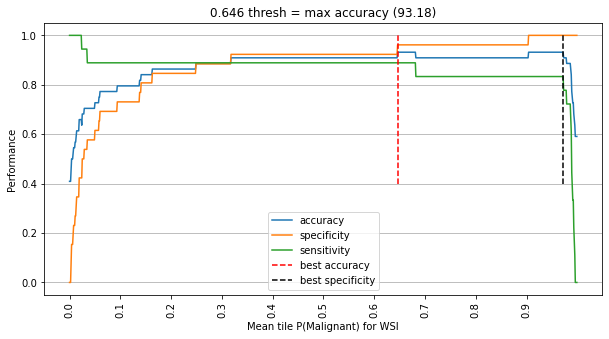

In [63]:
kfold = 10
# nrep = 10
seed = 35
valid_preds = pd.DataFrame(np.zeros((slide_df.shape[0],nrep))+np.nan)
valid_preds.index = slide_df.index
rep=-1
fold_rep=0
infer_test = []

for slide_train_idx, slide_test_idx in splitter.split(slide_df.loc[:, 'slide'],
                                                  slide_df.loc[:, 'group'],
                                                  groups=slide_df.loc[:, 'slide']):

    fold = fold_rep % kfold
    if fold == 0:
        rep = rep+1
        # print('\n Rep %d, Fold: ' % rep , end='')
    
    if rep == 0:
        #Remember:
        infer_test.append(slide_test_idx)
        
    overlap = pd.Series(slide_test_idx).isin(infer_test[fold]).values
    if any(overlap):
        slide_test_idx = slide_test_idx[overlap]
        X_val = all_feat_valid[slide_test_idx,:]
        y_val = slide_df.loc[slide_test_idx,'class'].values.astype(float)
        est = keep_ests[fold_rep]
        pred_gb =   est.predict(X_val)
        if use_rf:
            est_rf = keep_rf_ests[fold_rep]
            pred_rf = est_rf.predict_proba(X_val)[:,1]
            valid_preds.iloc[slide_test_idx,rep]= (pred_gb*0.9 + pred_rf * 0.1)
        else:
            valid_preds.iloc[slide_test_idx,rep]= pred_gb
    fold_rep = fold_rep + 1
a = []
sp = []
sn = []
t = np.arange(0.0,1,0.001)
y_true = slide_df.loc[:,'class'].values.astype(int)
# use_reps=[0]
use_reps = [x for x in range(0,nrep)]
for i in t:
    y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1)> i
    c = np.sum(y_true == y_pred)
    cm = skm.confusion_matrix(y_true, y_pred.astype(int))
    accuracy = c/len(y_true)
    a.append(accuracy)
    specificity = cm[0,0] / np.sum(cm,axis=1)[0]
    sp.append(specificity)
    sensitivity = cm[1,1] /  np.sum(cm,axis=1)[1]
    sn.append(sensitivity)
    
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(t,a,label='accuracy')
best_t = t[np.argwhere(a==np.max(a))[0]]
ax.set_title('%1.3f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))

ax.plot(t,sp,label='specificity')
ax.plot(t,sn,label='sensitivity')
plt.xticks(np.arange(0,1,0.1),rotation=90)
ax.plot([best_t,best_t],[0.4,1],'--r',label='best accuracy')

best_spec = max_best_spec(t,sp,a) # 

ax.plot([best_spec,best_spec],[0.4,1],'--k',label='best specificity')
print('Best specificity',best_spec)
ax.set_ylabel('Performance')
ax.set_xlabel('Mean tile P(Malignant) for WSI')
ax.legend()
plt.grid(axis='y')


Accuracy 0.9166666666666667 
Specificity 1.0 
Sensitivity 0.8333333333333334

Accuracy 0.9252136752136753 
Specificity 0.9615384615384616 
Sensitivity 0.8888888888888888


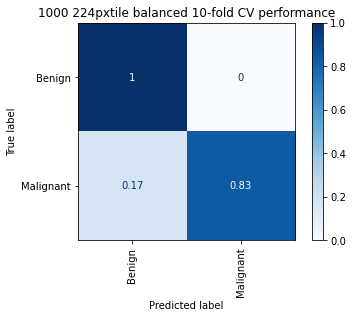

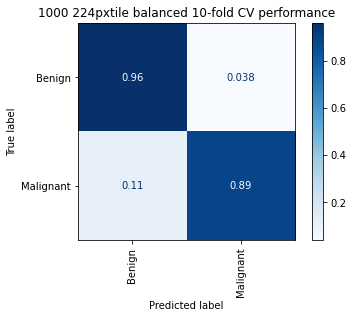

In [64]:
table_norm = True
# use_reps= [0]
use_reps = [x for x in range(0,nrep)]
y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_spec
y_true = slide_df.loc[:,'class'].values
cm = skm.confusion_matrix(y_true.astype(float), 
                          y_pred.astype(float))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('1000 224pxtile balanced 10-fold CV performance')


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

y_pred = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1) > best_t
y_true = slide_df.loc[:,'class'].values
cm = skm.confusion_matrix(y_true.astype(float), 
                          y_pred.astype(float))
if table_norm:
    cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign','Malignant'])
ax=disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.title('1000 224pxtile balanced 10-fold CV performance')


ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
sp = cm[0,0] / np.sum(cm,axis=1)[0]
sen = cm[1,1] /  np.sum(cm,axis=1)[1]
print('\nAccuracy',ac, 
      '\nSpecificity',sp,
      '\nSensitivity',sen)

In [11]:
slide_df.loc[y_true != y_pred,:]

,accession_number,pathologic_diagnosis,follow-up_diagnosis,notes,slide_num,anno_class,raw_fn,anno_pnfn,class,slide,group
0,PHS15-7377 - 1007831,Adenocarcinoma,NaN,NaN,1007831,malignant,PHS15-7377 - 1007831.svs,/mnt/data/biliseq_he_class/annotations/maligna...,True,1007831,malignant
22,PHS21-24702 - 1010162,Adenocarcinoma,NaN,NaN,1010162,malignant,PHS21-24702 - 1010162.svs,/mnt/data/biliseq_he_class/annotations/maligna...,True,1010162,malignant
38,PHS20-32143 - 1007477,Adenocarcinoma,NaN,NaN,1007477,malignant,PHS20-32143 - 1007477.svs,/mnt/data/biliseq_he_class/annotations/maligna...,True,1007477,malignant


43 43


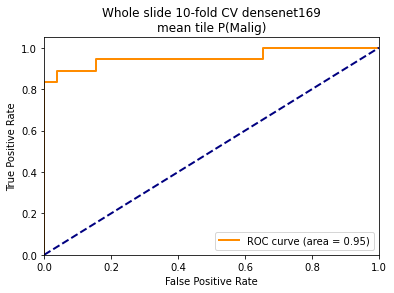

In [412]:
# use_reps= [0]
use_reps = [x for x in range(0,10)]
y_score = np.nanmean(valid_preds.iloc[:,use_reps].values,axis=1)
y_true = more_feat.iloc[:,-1].values.astype(float)
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=False)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whole slide 10-fold CV densenet169\nmean tile P(Malig)")
plt.legend(loc="lower right")
plt.show()
